# SUPERMARKET ANALYSIS

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from statistics import mode

from IPython.display import Image # for displaying images in Jupyter notebooks
sns.set_style('darkgrid') # set the style for seaborn plots

In [2]:
# Load the dataset
df = pd.read_csv('Supermarket Sales 2.csv')
df.head()

,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating
0,1/1/2024,Brooklyn,Member,Female,Food & Beverages,84.63,10,Credit card,9.0
1,1/1/2024,Queens,Normal,Female,Electronics,63.22,2,Cash,8.5
2,1/1/2024,Brooklyn,Normal,Female,Electronics,74.71,6,Cash,6.7
3,1/1/2024,Queens,Member,Female,Sports & Travel,36.98,10,Credit card,7.0
4,1/1/2024,Manhattan,Member,Female,Sports & Travel,27.04,4,Ewallet,6.9


In [ ]:
# Check for missing values
df.isnull().sum()

Date             0
Branch           0
Customer type    0
Gender           0
Product line     0
Unit price       0
Quantity         0
Payment          0
Rating           0
dtype: int64

In [ ]:
# Check the data types of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5053 entries, 0 to 5052
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           5053 non-null   object 
 1   Branch         5053 non-null   object 
 2   Customer type  5053 non-null   object 
 3   Gender         5053 non-null   object 
 4   Product line   5053 non-null   object 
 5   Unit price     5053 non-null   float64
 6   Quantity       5053 non-null   int64  
 7   Payment        5053 non-null   object 
 8   Rating         5053 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 355.4+ KB


1. The average revenue generated per transaction and total quantity of products sold.

In [ ]:
# Calculate the total money spent for each transaction
df['TotalMoney'] = df['Unit price'] * df['Quantity']
df.head()

,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating,TotalMoney
0,1/1/2024,Brooklyn,Member,Female,Food & Beverages,84.63,10,Credit card,9.0,846.30
1,1/1/2024,Queens,Normal,Female,Electronics,63.22,2,Cash,8.5,126.44
2,1/1/2024,Brooklyn,Normal,Female,Electronics,74.71,6,Cash,6.7,448.26
3,1/1/2024,Queens,Member,Female,Sports & Travel,36.98,10,Credit card,7.0,369.80
4,1/1/2024,Manhattan,Member,Female,Sports & Travel,27.04,4,Ewallet,6.9,108.16


In [ ]:
# Get summary statistics for the numerical columns
df[['Unit price', 'Quantity', 'TotalMoney']].describe() #

,Unit price,Quantity,TotalMoney
count,5053.000000,5053.000000,5053.000000
mean,39.692988,4.593509,186.531734
std,29.557474,2.787934,200.196697
min,2.010000,1.000000,2.180000
25%,11.630000,2.000000,38.520000
50%,33.900000,4.000000,109.600000
75%,64.940000,7.000000,266.560000
max,99.960000,10.000000,993.000000


2. Identification of the transaction with the highest purchase volume.

In [ ]:
# Find the transaction with the highest unit price
df.loc[df['Unit price'] == max(df['Unit price'])]

,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating,TotalMoney
233,1/23/2024,Queens,Normal,Male,Health & Beauty,99.96,7,Cash,6.1,699.72
768,3/9/2024,Brooklyn,Member,Male,Sports & Travel,99.96,9,Credit card,4.2,899.64
1183,4/9/2024,Brooklyn,Member,Male,Sports & Travel,99.96,9,Credit card,4.2,899.64


3. The distribution of the quantity, price, and total revenue variables.

In [ ]:
# Find the transaction with the highest quantity sold
df.loc[df['Quantity']==max(df['Quantity'])]

,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating,TotalMoney
0,1/1/2024,Brooklyn,Member,Female,Food & Beverages,84.63,10,Credit card,9.0,846.3
3,1/1/2024,Queens,Member,Female,Sports & Travel,36.98,10,Credit card,7.0,369.8
11,1/1/2024,Manhattan,Member,Female,Electronics,74.22,10,Credit card,4.3,742.2
17,1/2/2024,Brooklyn,Normal,Female,Health & Beauty,34.21,10,Cash,5.1,342.1
31,1/4/2024,Manhattan,Member,Female,Home & Lifestyle,35.54,10,Ewallet,7.0,355.4
...,...,...,...,...,...,...,...,...,...,...
5022,12/30/2024,Brooklyn,Normal,Female,Electronics,83.05,10,Ewallet,5.1,830.5
5042,12/31/2024,Manhattan,Member,Male,Food & Beverages,8.64,10,Cash,8.4,86.4
5045,12/31/2024,Manhattan,Member,Male,Health & Beauty,25.32,10,Ewallet,3.3,253.2
5048,12/31/2024,Manhattan,Normal,Female,Food & Beverages,6.71,10,Cash,5.9,67.1


In [ ]:
# Analyze the unit price for transactions with the highest quantity sold
dfMaxQuantity = df.loc[df['Quantity']==max(df['Quantity'])]
dfMaxQuantity['Unit price'].describe()

count    342.000000
mean      42.879678
std       29.663489
min        2.100000
25%       14.927500
50%       39.900000
75%       68.600000
max       99.300000
Name: Unit price, dtype: float64

In [ ]:
# Find the transaction with the lowest quantity sold
dfMaxQuantity = df.loc[df['Quantity']==min(df['Quantity'])]
dfMaxQuantity['Unit price'].describe()

count    675.000000
mean      41.629363
std       30.269727
min        2.180000
25%       12.725000
50%       35.550000
75%       67.715000
max       99.830000
Name: Unit price, dtype: float64

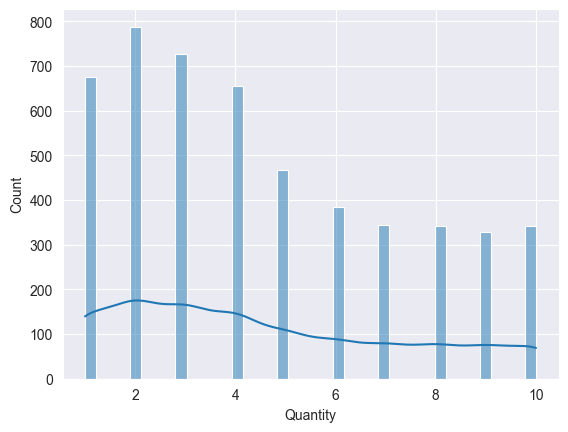

In [ ]:
# Analyze the distribution of the quantity sold
sns.histplot(df['Quantity'], bins=40, kde=True)
plt.show()

<Axes: xlabel='TotalMoney', ylabel='Count'>

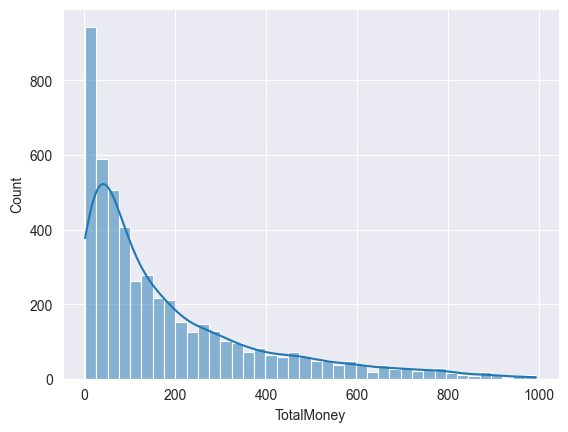

In [12]:
sns.histplot(data=df, x='TotalMoney', bins=40, kde=True)

4. The correlation between price and quantity.

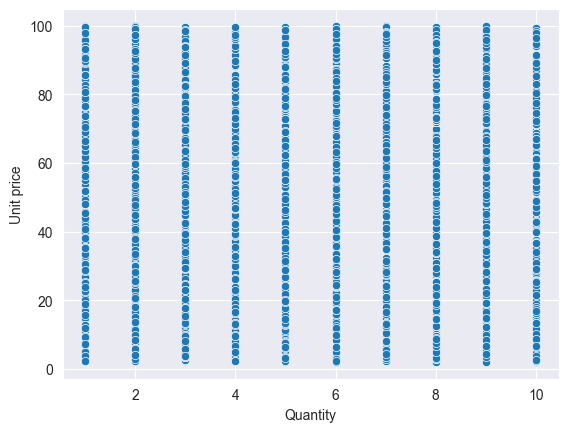

In [13]:
sns.scatterplot(data=df, y='Unit price', x='Quantity')
plt.show()

In [ ]:
# Analyze the correlation between unit price and quantity sold
df[['Unit price', 'Quantity']].corr()

,Unit price,Quantity
Unit price,1.000000,0.050998
Quantity,0.050998,1.000000


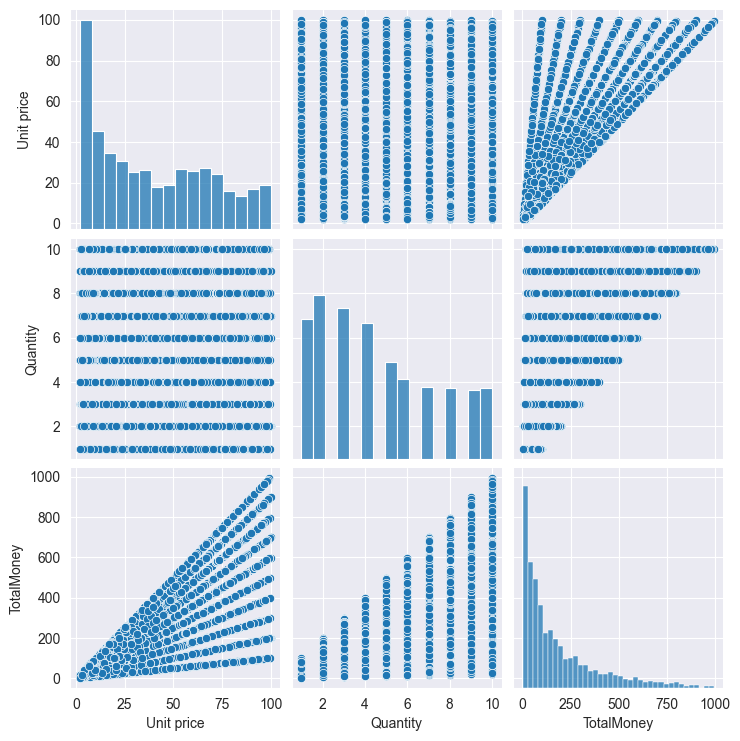

In [ ]:
# Analyze the correlation between unit price, quantity sold, and total money spent

sns.pairplot(df[['Unit price', 'Quantity', 'TotalMoney']])
plt.show()

In [16]:
df.head()

,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating,TotalMoney
0,1/1/2024,Brooklyn,Member,Female,Food & Beverages,84.63,10,Credit card,9.0,846.30
1,1/1/2024,Queens,Normal,Female,Electronics,63.22,2,Cash,8.5,126.44
2,1/1/2024,Brooklyn,Normal,Female,Electronics,74.71,6,Cash,6.7,448.26
3,1/1/2024,Queens,Member,Female,Sports & Travel,36.98,10,Credit card,7.0,369.80
4,1/1/2024,Manhattan,Member,Female,Sports & Travel,27.04,4,Ewallet,6.9,108.16


5. The region with the highest number of transactions.

In [ ]:
# Analyze the percentage of transactions by country
dfCountryTransaction = pd.DataFrame(data={'Region' : df['Branch'].value_counts(normalize=True).index,
                                'Percentage Transaction' : df['Branch'].value_counts(normalize=True).values*100})
dfCountryTransaction.head()

,Region,Percentage Transaction
0,Brooklyn,35.483871
1,Manhattan,33.742331
2,Queens,30.773798


In [18]:
df['Branch'].unique()

array(['Brooklyn', 'Queens', 'Manhattan'], dtype=object)

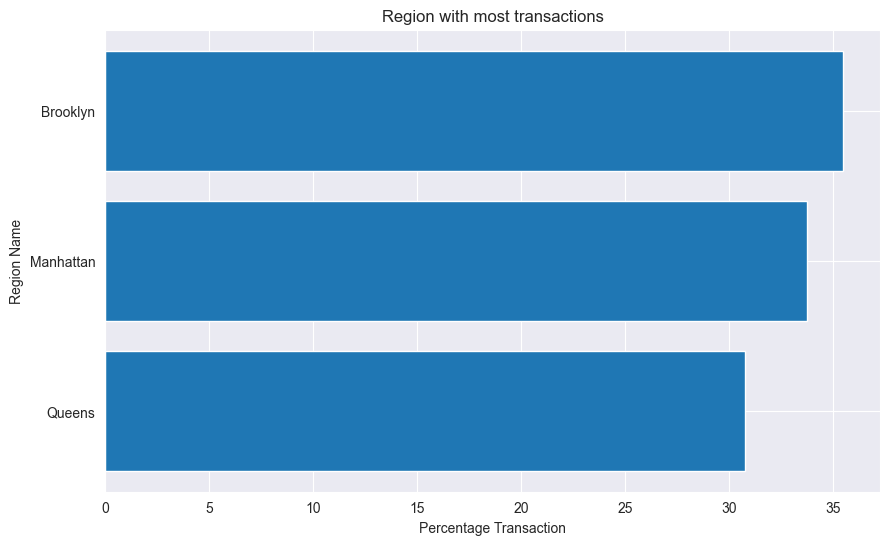

In [ ]:
# Visualize the percentage of transactions by country
plt.figure(figsize=(10,6))
dfbarplot = dfCountryTransaction.sort_values(by='Percentage Transaction', ascending=True)
plt.barh(data=dfbarplot, y = 'Region', width='Percentage Transaction')
plt.title('Region with most transactions')
plt.xlabel('Percentage Transaction')
plt.ylabel('Region Name')
plt.show()

6. What are the most frequently purchased products?

In [ ]:
# Analyze the percentage of transactions by product line
dfProductTransaction = pd.DataFrame(data={'Product line' : df['Product line'].value_counts(normalize=True).index,
                                'Percentage Transaction' : df['Product line'].value_counts(normalize=True).values*100})

In [21]:
dfProductTransaction

,Product line,Percentage Transaction
0,Food & Beverages,33.049673
1,Health & Beauty,18.959034
2,Home & Lifestyle,14.011478
3,Fashion & Accs,13.378191
4,Sports & Travel,11.399169
5,Electronics,9.202454


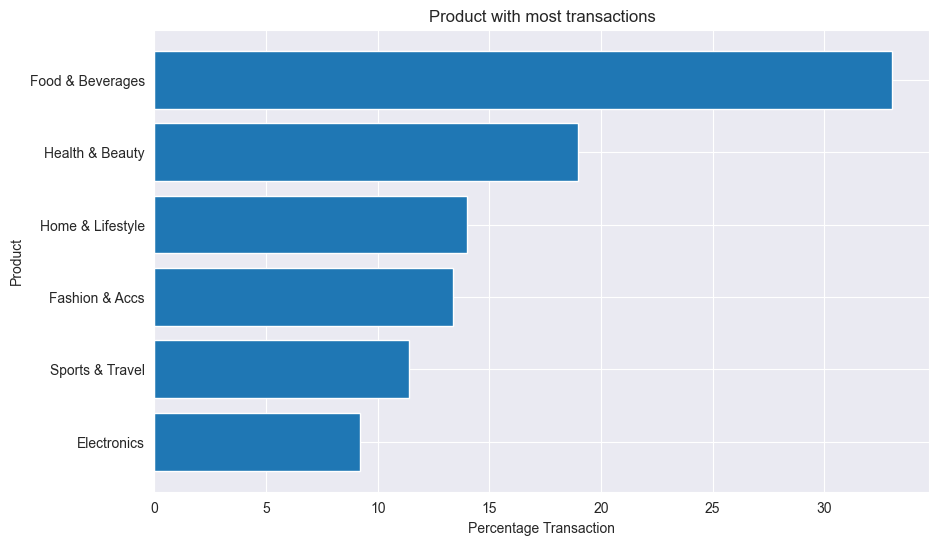

In [22]:
plt.figure(figsize=(10,6))
dfbarplot = dfProductTransaction.sort_values(by='Percentage Transaction', ascending=True)
plt.barh(data=dfbarplot, y = 'Product line', width='Percentage Transaction')
plt.title('Product with most transactions')
plt.xlabel('Percentage Transaction')
plt.ylabel('Product')
plt.show()

In [23]:
df['gender'] = np.where(df['Gender'] == 'Male', 'M', 'F')

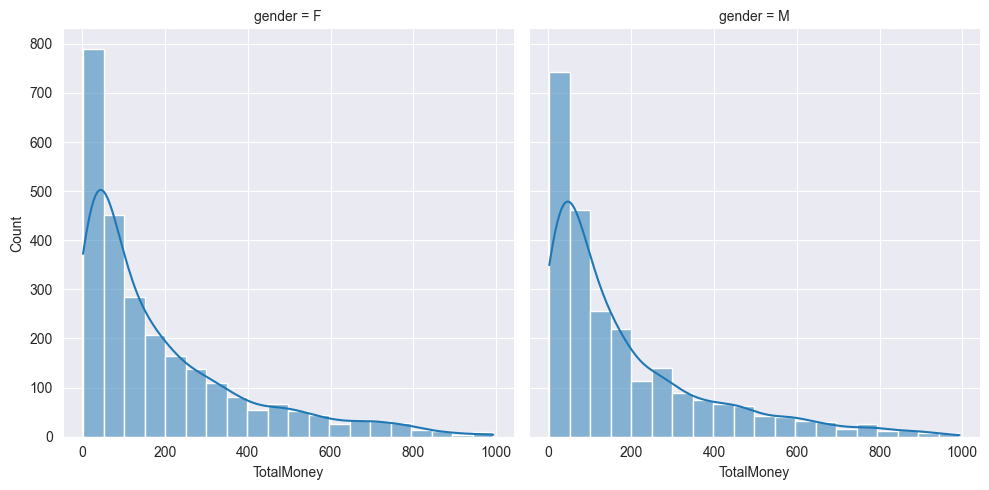

In [24]:
sns.displot(df, x = 'TotalMoney', col='gender', bins=20, kde=True)

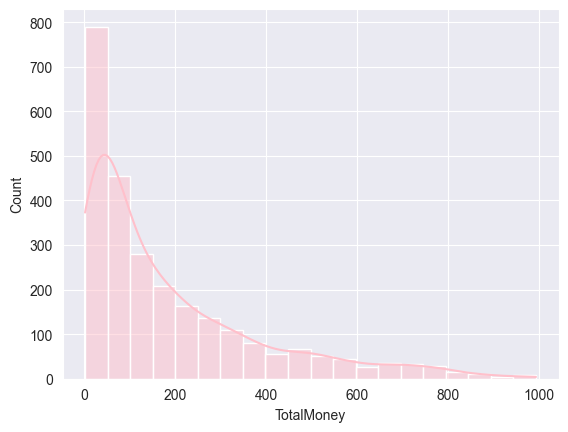

In [25]:
sns.histplot(df['TotalMoney'].loc[df['gender']=='F'], bins=20, kde=True, color='pink')
plt.show()

7. Which region generates the highest and lowest total revenue?

In [ ]:
# Analyze the total money spent by country
dfCountryTotalMoney = df.groupby('Branch')[['TotalMoney']].sum().sort_values('TotalMoney', ascending=False).reset_index()
dfCountryTotalMoney

,Branch,TotalMoney
0,Brooklyn,319705.48
1,Queens,312842.82
2,Manhattan,309996.55


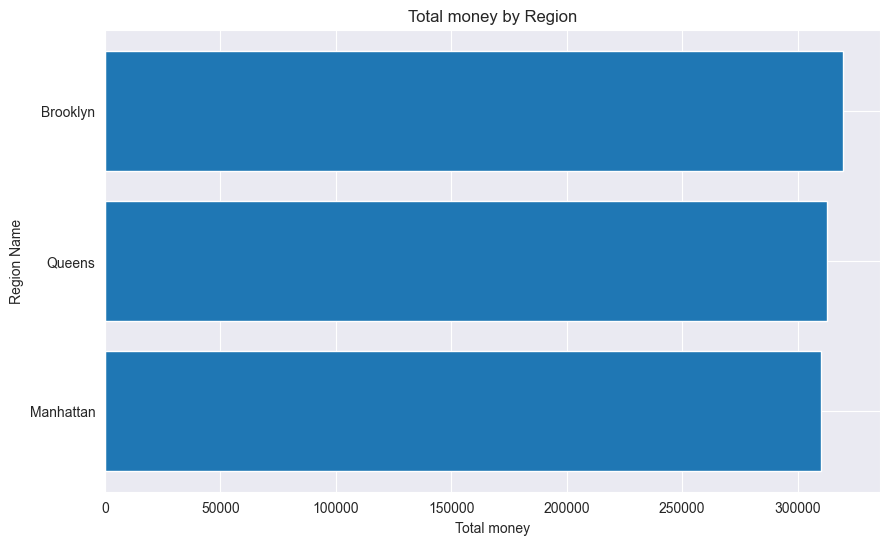

In [26]:
plt.figure(figsize=(10,6))
dfbarplot = dfCountryTotalMoney.sort_values('TotalMoney', ascending=True)
plt.barh(data=dfbarplot, y = 'Branch', width='TotalMoney')
plt.title('Total money by Region')
plt.xlabel('Total money')
plt.ylabel('Region Name')
plt.show()

8. What was the sales trend over the months?

In [ ]:
# Analyze the total money spent by product line
dateFormat = '%Y-%m-%d'
df['Date'] = pd.to_datetime(df['Date'], format=dateFormat)

# create a new column 'Month' by extracting the month from the 'Date' column
df['Month'] = pd.DatetimeIndex(df['Date']).month

Text(0.5, 1.0, 'Number of transactions by month')

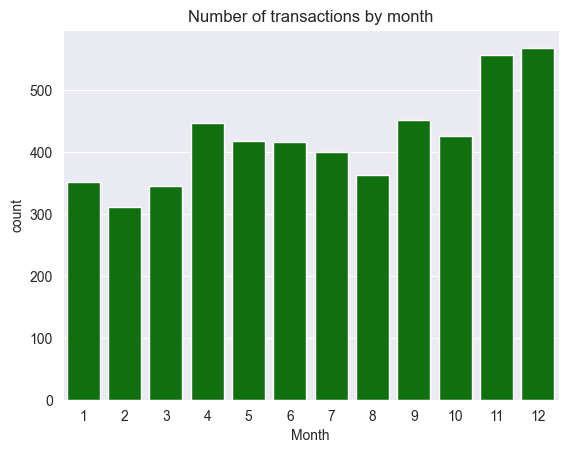

In [32]:
sns.countplot(x=df['Month'], color='green').set_title('Number of transactions by month')

In [ ]:
# Analyze the most common month for transactions
mode(df['Month'])

12

In [ ]:
# Analyze the total money spent by month
month = sorted(df['Month'].unique())
listMonth = [dt.datetime.strptime(str(i), '%m').strftime('%b') for i in month] # convert month number to month name
listTotalMoney = [df['TotalMoney'].loc[df['Month']==i].sum() for i in month]
dfMonth = pd.DataFrame(data={'Month' : listMonth, 'TotalMoney' : listTotalMoney})
dfMonth.head()

,Month,TotalMoney
0,Jan,110754.16
1,Feb,94761.64
2,Mar,104243.34
3,Apr,132083.88
4,May,60955.78


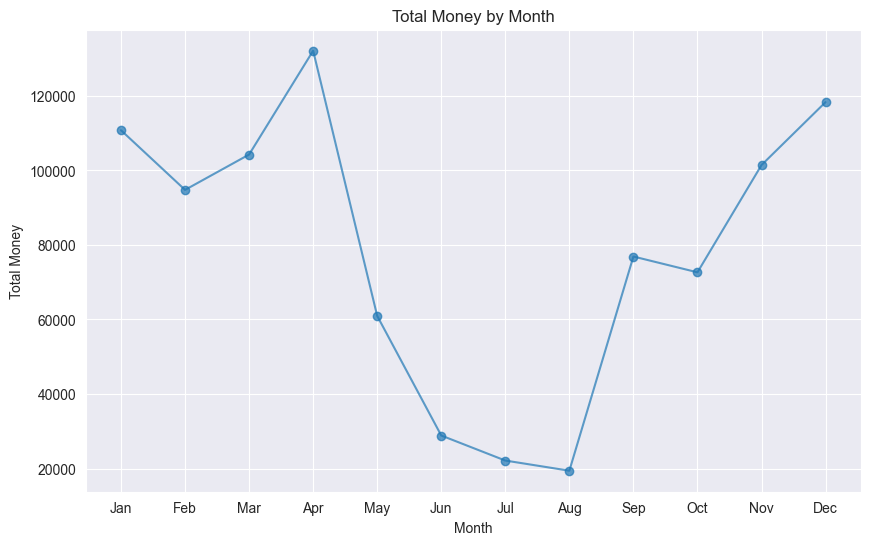

In [35]:
plt.figure(figsize=(10,6))
plt.plot(dfMonth['Month'], dfMonth['TotalMoney'], marker='o', alpha=0.7)
plt.xlabel('Month')
plt.ylabel('Total Money')
plt.title('Total Money by Month')
plt.show()

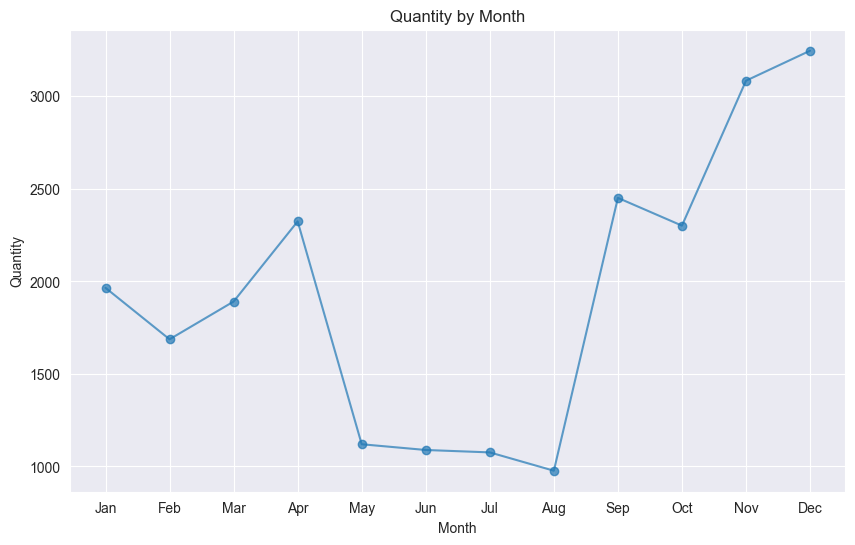

In [ ]:
# Analyze the quantity sold by month
month = sorted(df['Month'].unique())
listMonth = [dt.datetime.strptime(str(i), '%m').strftime('%b') for i in month]
listQuantity = [df['Quantity'].loc[df['Month']==i].sum() for i in month]
dfMonthQuantity = pd.DataFrame(data={'Month' : listMonth, 'Quantity' : listQuantity})

plt.figure(figsize=(10,6))
plt.plot(dfMonthQuantity['Month'], dfMonthQuantity['Quantity'], marker='o', alpha=0.7)
plt.xlabel('Month')
plt.ylabel('Quantity')
plt.title('Quantity by Month')
plt.show()

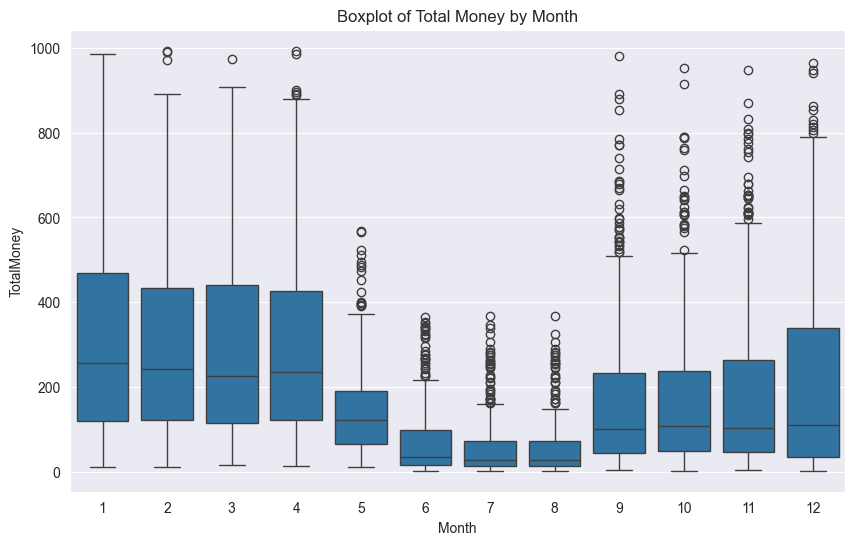

In [ ]:
# Analyze the distribution of total money spent by month
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Month', y='TotalMoney')
plt.title('Boxplot of Total Money by Month')
plt.show()

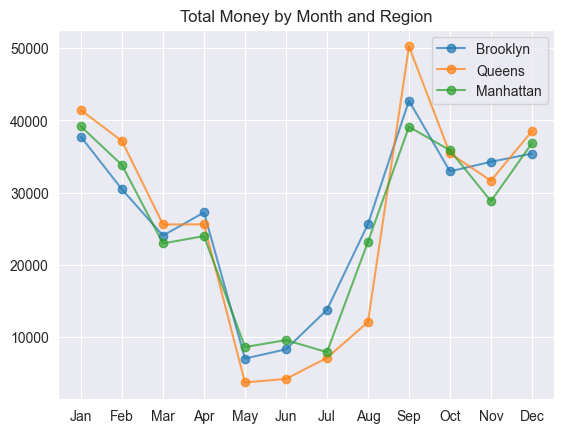

In [ ]:
# Analyze the total money spent by month and region
plt.Figure(figsize=(10,6))
salescountry = dfCountryTotalMoney['Branch'].unique().copy()
listMonthbrach = listMonth

for i in salescountry:
    totalMoneyCity = [round(df['TotalMoney'].loc[(df['Branch']==i) & (df['Month']==j)].sum(), 2) for j in month]
    totalMoneyCity.reverse()
    plt.plot(listMonthbrach, totalMoneyCity, marker='o', alpha=0.7, label=i)

plt.title('Total Money by Month and Region')
plt.legend()
plt.show()


9. Which products contribute the most to the total transaction earnings?

In [ ]:
# Analyze the total money spent by product line
dfProduct = df.groupby('Product line')[['TotalMoney']].sum().sort_values('TotalMoney', ascending=False).reset_index()
dfProduct

,Product line,TotalMoney
0,Home & Lifestyle,197260.56
1,Health & Beauty,168570.61
2,Sports & Travel,164252.94
3,Electronics,159259.10
4,Food & Beverages,151357.73
5,Fashion & Accs,101843.91


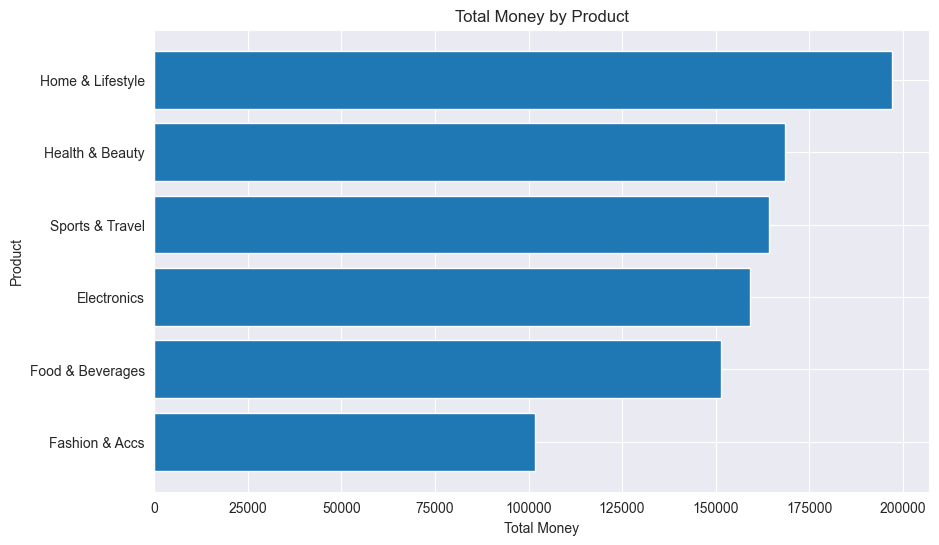

In [42]:
plt.figure(figsize=(10,6))
dfbarplot = dfProduct.sort_values('TotalMoney', ascending=True)
plt.barh(data=dfbarplot, y = 'Product line', width='TotalMoney')
plt.title('Total Money by Product')
plt.xlabel('Total Money')
plt.ylabel('Product')
plt.show()

In [ ]:
df['Product line'].unique()

array(['Food & Beverages', 'Electronics', 'Sports & Travel',
       'Fashion & Accs', 'Home & Lifestyle', 'Health & Beauty'],
      dtype=object)

Based on your findings, what strategies would you recommend to the business to maximize profit?

In [ ]:
# Analyze the total money spent on Home & Lifestyle product line
df.loc[df['Product line']=='Home & Lifestyle']

,Date,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating,TotalMoney,gender,Month
6,2024-01-01,Manhattan,Member,Male,Home & Lifestyle,47.59,8,Cash,5.7,380.72,M,1
20,2024-01-03,Brooklyn,Normal,Female,Home & Lifestyle,63.15,6,Ewallet,9.8,378.90,F,1
26,2024-01-03,Manhattan,Normal,Female,Home & Lifestyle,67.09,5,Credit card,9.1,335.45,F,1
31,2024-01-04,Manhattan,Member,Female,Home & Lifestyle,35.54,10,Ewallet,7.0,355.40,F,1
36,2024-01-05,Brooklyn,Member,Female,Home & Lifestyle,35.38,9,Credit card,9.6,318.42,F,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5015,2024-12-30,Manhattan,Normal,Female,Home & Lifestyle,66.44,1,Credit card,4.1,66.44,F,12
5024,2024-12-30,Queens,Normal,Female,Home & Lifestyle,66.80,3,Ewallet,8.0,200.40,F,12
5028,2024-12-30,Brooklyn,Normal,Male,Home & Lifestyle,60.87,9,Credit card,7.4,547.83,M,12
5038,2024-12-31,Brooklyn,Normal,Male,Home & Lifestyle,66.22,2,Credit card,7.6,132.44,M,12


In [ ]:
# Analyze the percentage of transactions by product line
dfProduct.join(dfProductTransaction.set_index('Product line'), on='Product line').sort_values(by='Percentage Transaction', ascending=False)

,Product line,TotalMoney,Percentage Transaction
4,Food & Beverages,151357.73,33.049673
1,Health & Beauty,168570.61,18.959034
0,Home & Lifestyle,197260.56,14.011478
5,Fashion & Accs,101843.91,13.378191
2,Sports & Travel,164252.94,11.399169
3,Electronics,159259.10,9.202454
